In [9]:
a = (1==1 or 1==2)
a = (1==2 or 1==1)
a = ('' or [])
a = (0 or [])
print(a)

[]


In [1]:
import threading
import time

def print_numbers(thread_name, start, end):
    """
    This function is executed by each thread to print numbers within a specified range.
    """
    print(f"Starting {thread_name}")
    for i in range(start, end + 1):
        print(f"{thread_name}: {i}")
        # Add a small delay to better see the interleaving of threads
        time.sleep(0.1)
    print(f"Exiting {thread_name}")

# Create two threads
thread1 = threading.Thread(target=print_numbers, args=("Thread 1", 1, 5))
thread2 = threading.Thread(target=print_numbers, args=("Thread 2", 6, 10))

# Start the threads
thread1.start()
thread2.start()

# Wait for both threads to complete
thread1.join()
thread2.join()

print("Main thread: All threads have finished.")

Starting Thread 1
Thread 1: 1
Starting Thread 2
Thread 2: 6
Thread 1: 2
Thread 2: 7
Thread 1: 3
Thread 2: 8
Thread 1: 4
Thread 2: 9
Thread 1: 5
Thread 2: 10
Exiting Thread 1
Exiting Thread 2
Main thread: All threads have finished.


In [2]:
import threading
import time

# A function to be executed by each thread
def worker_function(thread_name, delay):
    """
    This function simulates a task by printing a message and then sleeping.
    """
    print(f"Thread {thread_name}: starting.")
    for i in range(3):
        time.sleep(delay)
        print(f"Thread {thread_name}: running... step {i+1}")
    print(f"Thread {thread_name}: finished.")

# Create two threads
thread1 = threading.Thread(target=worker_function, args=("One", 1))
thread2 = threading.Thread(target=worker_function, args=("Two", 0.5))

# Start the threads
thread1.start()
thread2.start()

# Wait for both threads to complete
thread1.join()
thread2.join()

print("\nMain program: All threads have completed their tasks.")

Thread One: starting.
Thread Two: starting.
Thread Two: running... step 1
Thread One: running... step 1
Thread Two: running... step 2
Thread Two: running... step 3
Thread Two: finished.
Thread One: running... step 2
Thread One: running... step 3
Thread One: finished.

Main program: All threads have completed their tasks.


In [4]:
es

{'customers':    customer_id zip_code           join_date   birthday
 0            1    60091 2011-04-17 10:48:33 1994-07-18
 1            2    13244 2012-04-15 23:31:04 1986-08-18
 2            3    13244 2011-08-13 15:42:34 2003-11-21
 3            4    60091 2011-04-08 20:08:14 2006-08-15
 4            5    60091 2010-07-17 05:27:50 1984-07-28,
 'sessions':     session_id  customer_id   device       session_start
 0            1            2  desktop 2014-01-01 00:00:00
 1            2            5   mobile 2014-01-01 00:17:20
 2            3            4   mobile 2014-01-01 00:28:10
 3            4            1   mobile 2014-01-01 00:44:25
 4            5            4   mobile 2014-01-01 01:11:30
 5            6            1   tablet 2014-01-01 01:23:25
 6            7            3   tablet 2014-01-01 01:39:40
 7            8            4   tablet 2014-01-01 01:55:55
 8            9            1  desktop 2014-01-01 02:15:25
 9           10            2   tablet 2014-01-01 02:31:40


In [11]:
import featuretools as ft
import pandas as pd

es = ft.EntitySet("customer_data")
data = ft.demo.load_mock_customer()
data['sessions']['session_start'] = pd.to_datetime(
    data['sessions']['session_start'],
    format='%Y-%m-%d %H:%M:%S'  # Adjust format based on your actual data
)
# Add the dataframes to the entityset
es = es.add_dataframe(
    dataframe_name="customers",
    dataframe=data["customers"],
    index="customer_id"
)

# Add other dataframes similarly
es = es.add_dataframe(
    dataframe_name="sessions",
    dataframe=data["sessions"],
    index="session_id",
    time_index="session_start",
    logical_types={"device": "Categorical"}
)

# Add relationships
es = es.add_relationship("customers", "customer_id", "sessions", "customer_id")

feature_matrix, feature_defs = ft.dfs(
    entityset=es,
    target_dataframe_name='customers',
    max_depth=2
)

print(feature_matrix.head())

             zip_code  COUNT(sessions) MODE(sessions.device)  \
customer_id                                                    
1               60091                8                mobile   
2               13244                7               desktop   
3               13244                6               desktop   
4               60091                8                mobile   
5               60091                6                mobile   

             NUM_UNIQUE(sessions.device) DAY(birthday) DAY(join_date)  \
customer_id                                                             
1                                      3            18             17   
2                                      3            18             15   
3                                      3            21             13   
4                                      3            15              8   
5                                      3            28             17   

            MONTH(birthday) MONTH(join_

/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(


In [9]:
data = ft.demo.load_mock_customer()
print("Type of returned data:", type(data))
print("Keys in returned data:", list(data.keys()))

Type of returned data: <class 'dict'>
Keys in returned data: ['customers', 'sessions', 'transactions', 'products']


In [14]:
import pandas as pd
from io import StringIO

data = """client_id\tloan_type\tloan_amount\trepaid\tloan_id\tloan_start\tloan_end\trate
46109\thome\t13672\t0\t10243\t2002-04-16\t2003-12-20\t2.15
46109\tcredit\t9794\t0\t10984\t2003-10-21\t2005-07-17\t1.25
46109\thome\t12734\t1\t10990\t2006-02-01\t2007-07-05\t0.68
46109\tcash\t12518\t1\t10596\t2010-12-08\t2013-05-05\t1.24
46109\tcredit\t14049\t1\t11415\t2010-07-07\t2012-05-21\t3.13
46109\thome\t6935\t0\t11501\t2006-09-17\t2008-11-26\t1.94
46109\tcash\t6177\t1\t11141\t2007-03-12\t2009-04-26\t9.48
46109\thome\t12656\t0\t11658\t2006-05-26\t2007-10-15\t4.14
46109\thome\t11062\t1\t11611\t2012-09-12\t2014-03-14\t5.48
46109\tother\t4050\t1\t10828\t2003-12-06\t2005-08-19\t4.26
"""

df = pd.read_csv(StringIO(data), sep='\t')
print(df)
X = df.drop(['client_id','loan_id','loan_type','loan_start','loan_end'], axis=1)
y = df['repaid']

   client_id loan_type  loan_amount  repaid  loan_id  loan_start    loan_end  \
0      46109      home        13672       0    10243  2002-04-16  2003-12-20   
1      46109    credit         9794       0    10984  2003-10-21  2005-07-17   
2      46109      home        12734       1    10990  2006-02-01  2007-07-05   
3      46109      cash        12518       1    10596  2010-12-08  2013-05-05   
4      46109    credit        14049       1    11415  2010-07-07  2012-05-21   
5      46109      home         6935       0    11501  2006-09-17  2008-11-26   
6      46109      cash         6177       1    11141  2007-03-12  2009-04-26   
7      46109      home        12656       0    11658  2006-05-26  2007-10-15   
8      46109      home        11062       1    11611  2012-09-12  2014-03-14   
9      46109     other         4050       1    10828  2003-12-06  2005-08-19   

   rate  
0  2.15  
1  1.25  
2  0.68  
3  1.24  
4  3.13  
5  1.94  
6  9.48  
7  4.14  
8  5.48  
9  4.26  


In [13]:
import featuretools as ft

# Create an empty EntitySet
es = ft.EntitySet(id="customer_data")

# Add the dataframe to the EntitySet
es = es.add_dataframe(dataframe_name='client_id', dataframe=df, index='id', make_index=True)

# Run DFS (Deep Feature Synthesis) to automatically generate features
feature_matrix, feature_defs = ft.dfs(entityset=es,
                                      target_dataframe_name="client_id",
                                      trans_primitives=['time_since', 'day', 'is_weekend',
                                                        'cum_min', 'minute',
                                                        'num_words', 'weekday', 'cum_count',
                                                        'percentile', 'year', 'week',
                                                        'cum_mean'])

# List the generated features
print(list(feature_matrix))

['client_id', 'loan_amount', 'repaid', 'loan_id', 'rate', 'CUM_MEAN(client_id)', 'CUM_MEAN(loan_amount)', 'CUM_MEAN(loan_id)', 'CUM_MEAN(rate)', 'CUM_MEAN(repaid)', 'CUM_MIN(client_id)', 'CUM_MIN(loan_amount)', 'CUM_MIN(loan_id)', 'CUM_MIN(rate)', 'CUM_MIN(repaid)', 'DAY(loan_end)', 'DAY(loan_start)', 'IS_WEEKEND(loan_end)', 'IS_WEEKEND(loan_start)', 'MINUTE(loan_end)', 'MINUTE(loan_start)', 'PERCENTILE(client_id)', 'PERCENTILE(loan_amount)', 'PERCENTILE(loan_id)', 'PERCENTILE(rate)', 'PERCENTILE(repaid)', 'TIME_SINCE(loan_end)', 'TIME_SINCE(loan_start)', 'WEEK(loan_end)', 'WEEK(loan_start)', 'WEEKDAY(loan_end)', 'WEEKDAY(loan_start)', 'YEAR(loan_end)', 'YEAR(loan_start)']


/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/featuretools/synthesis/deep_feature_synthesis.py:169: UserWarning: Only one dataframe in entityset, changing max_depth to 1 since deeper features cannot be created
  warnings.warn(
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/featuretools/synthesis/dfs.py:321: UnusedPrimitiveWarning: So

In [20]:
import os
print(os.getcwd())

/Users/stevegon/SynologyDrive/code/uw/IMT575


In [59]:
df = pd.read_excel("final_proj/daily.xlsx", parse_dates=['date']).dropna()
obj_cols = df.select_dtypes(include=['object']).columns
df[obj_cols] = df[obj_cols].astype(float)
es = ft.EntitySet(id="stock_info")
es = es.add_dataframe(dataframe_name='daily', dataframe=df, index='id', make_index=True)
f_matrix, f_defs = ft.dfs(entityset=es, target_dataframe_name="daily",
                          trans_primitives=['time_since', 'day', 'is_weekend', 'cum_min', 'minute',
                                            'num_words', 'weekday', 'cum_count', 'percentile', 'year', 'week', 'cum_mean'])

# List the generated features
print(list(f_matrix))

['aapl', 'adm', 'amzn', 'avgo', 'brk-b', 'f', 'fcx', 'gm', 'googl', 'meta', 'msft', 'nke', 'nvda', 'tsla', 'tsm', 'wmt', 'dji', 'gspc', 'population', 'women_lpr', 'men_lpr', 'civilian_lpr', 'civilian_ur', 'impca', 'impch', 'impfr', 'impge', 'impjp', 'impmx', 'impkr', 'impuk', 'gdp', 'CUM_MEAN(aapl)', 'CUM_MEAN(adm)', 'CUM_MEAN(amzn)', 'CUM_MEAN(avgo)', 'CUM_MEAN(brk-b)', 'CUM_MEAN(civilian_lpr)', 'CUM_MEAN(civilian_ur)', 'CUM_MEAN(dji)', 'CUM_MEAN(f)', 'CUM_MEAN(fcx)', 'CUM_MEAN(gdp)', 'CUM_MEAN(gm)', 'CUM_MEAN(googl)', 'CUM_MEAN(gspc)', 'CUM_MEAN(impca)', 'CUM_MEAN(impch)', 'CUM_MEAN(impfr)', 'CUM_MEAN(impge)', 'CUM_MEAN(impjp)', 'CUM_MEAN(impkr)', 'CUM_MEAN(impmx)', 'CUM_MEAN(impuk)', 'CUM_MEAN(men_lpr)', 'CUM_MEAN(meta)', 'CUM_MEAN(msft)', 'CUM_MEAN(nke)', 'CUM_MEAN(nvda)', 'CUM_MEAN(population)', 'CUM_MEAN(tsla)', 'CUM_MEAN(tsm)', 'CUM_MEAN(wmt)', 'CUM_MEAN(women_lpr)', 'CUM_MIN(aapl)', 'CUM_MIN(adm)', 'CUM_MIN(amzn)', 'CUM_MIN(avgo)', 'CUM_MIN(brk-b)', 'CUM_MIN(civilian_lpr)', 'CU

/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/featuretools/synthesis/deep_feature_synthesis.py:169: UserWarning: Only one dataframe in entityset, changing max_depth to 1 since deeper features cannot be created
  warnings.warn(
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/featuretools/synthesis/dfs.py:321: UnusedPrimitiveWarning: Some specified primitives were not used during DFS:
  trans_primitives: ['cum_count', 'num_words']
This may be caused by a using a value of max_depth that is too small, not setting interesting values, or it may indicate no compatible columns for the primitive were found in the data. If the DFS call contained multiple instances of a primitive in the list above, none of them were used.
  warnings.warn(warning_msg, UnusedPrimitiveWarning)


Mean Squared Error: 143863.80089817767
R^2 Score: -0.9105187647120705


<Figure size 1200x1500 with 0 Axes>

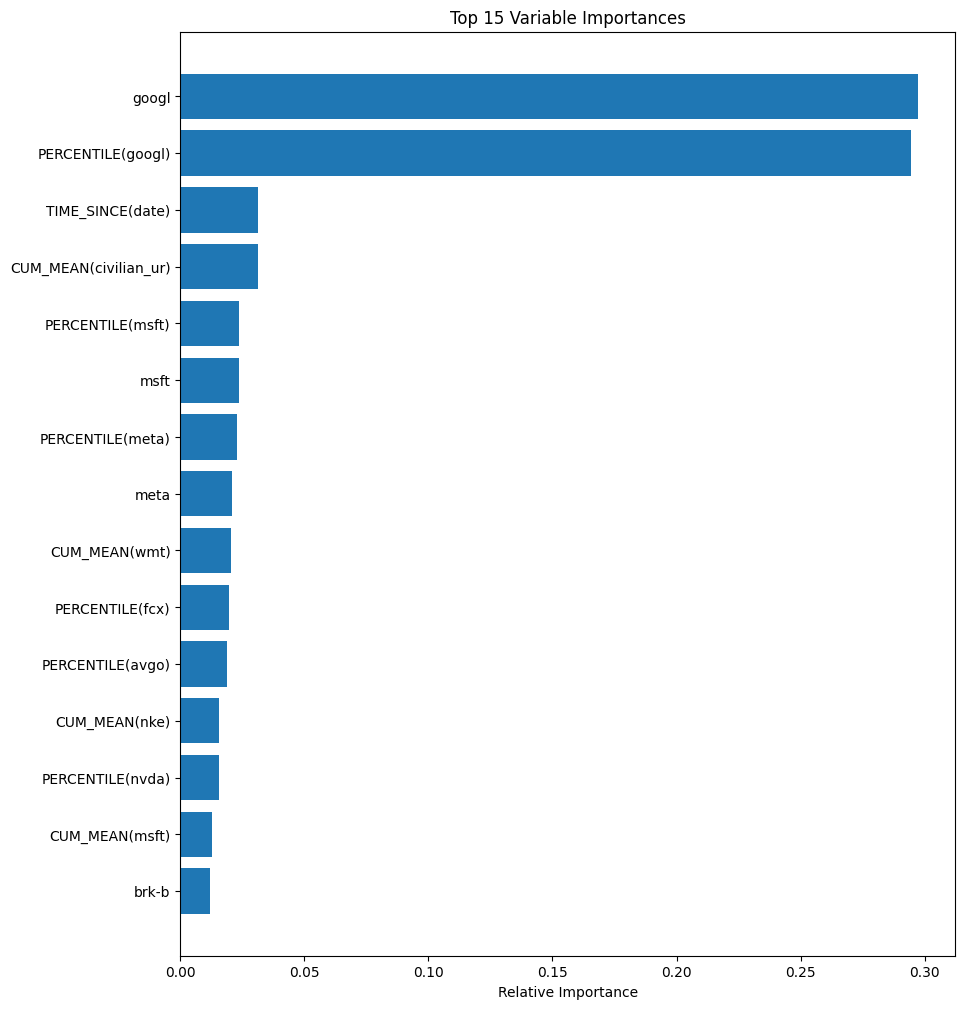

In [60]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Remove gspc from features
features = []
for f in f_matrix.columns:
    if 'gspc' not in f.lower() and 'dji' not in f.lower():
        features.append(f)
model = RandomForestRegressor(
        n_estimators=100,
        max_depth=8,
        random_state=42
    )
X_train, X_test, y_train, y_test = train_test_split(f_matrix[features], df['gspc'], test_size=0.2, shuffle=False)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)
# from the calculated importances, order them from most to least important
# and make a barplot so we can visualize what is/isn't important
plt.figure(figsize=(12, 15))
importances = model.feature_importances_
sorted_idx = np.argsort(importances)[-15:]  # indices of top 15

# Prepare labels and values
top_features = np.array(features)[sorted_idx]
top_importances = importances[sorted_idx]
padding = np.arange(len(top_features)) + 1

plt.figure(figsize=(10, 12))
plt.barh(padding, top_importances, align='center')
plt.yticks(padding, top_features)
plt.xlabel("Relative Importance")
plt.title("Top 15 Variable Importances")
plt.show()

In [31]:
f_matrix[features]

,aapl,adm,amzn,avgo,brk-b,f,fcx,gm,googl,meta,...,PERCENTILE(nvda),PERCENTILE(population),PERCENTILE(tsla),PERCENTILE(tsm),PERCENTILE(wmt),PERCENTILE(women_lpr),TIME_SINCE(date),WEEK(date),WEEKDAY(date),YEAR(date)
id,,,,,,,,,,,,,,,,,,,,,
0,113.01,44.45,158.11,33.36,213.24,7.11,13.97,28.03,75.36,259.89,...,0.002005,0.005613,0.000802,0.065758,0.065758,0.216119,1.581544e+08,33,2,2020
1,115.01,44.43,158.05,32.94,211.98,7.03,13.79,27.55,75.83,261.30,...,0.002005,0.005613,0.001604,0.052125,0.064956,0.216119,1.580680e+08,33,3,2020
2,114.91,44.59,157.40,32.78,210.96,7.04,13.78,27.86,75.23,261.24,...,0.004010,0.005613,0.004010,0.054531,0.081395,0.216119,1.579816e+08,33,4,2020
3,114.61,44.39,159.12,33.03,206.78,6.98,14.10,30.01,75.81,261.16,...,0.020850,0.005613,0.012029,0.075381,0.116279,0.216119,1.577224e+08,34,0,2020
4,115.56,44.31,165.62,32.86,208.33,6.89,14.41,29.84,77.79,262.34,...,0.019246,0.005613,0.020048,0.067362,0.105854,0.216119,1.576360e+08,34,1,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1242,213.76,55.50,232.23,288.71,480.60,11.26,44.58,52.34,192.17,714.80,...,0.997594,0.991580,0.821973,0.996792,0.951083,0.498797,2.029594e+06,30,3,2025
1243,213.88,55.35,231.44,290.18,484.07,11.47,44.89,53.40,193.18,712.68,...,0.996792,0.991580,0.845229,0.999599,0.966720,0.498797,1.943194e+06,30,4,2025
1244,214.05,54.76,232.79,294.30,481.70,11.28,43.79,53.45,192.58,717.63,...,0.999198,0.991580,0.862069,0.997594,0.971532,0.498797,1.683994e+06,31,0,2025


In [61]:
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

os.environ['PYTHONHASHSEED'] = '7'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(7)
np.random.seed(7)
tf.random.set_seed(7)

X_train, X_test, y_train, y_test = train_test_split(
    f_matrix[features], df['gspc'], test_size=0.2, shuffle=False, random_state=7
)

model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=100,
                    batch_size=32,
                    callbacks=[early_stop],
                    verbose=0)

# Predict and evaluate
y_pred = model.predict(X_test).flatten()
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Mean Squared Error: 1731595.7415277115
R^2 Score: -21.99568158515205


In [62]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Create binary target: 1 if next day's gspc is up, 0 if down
gspc = df['gspc'].values
target = (np.roll(gspc, -1) > gspc).astype(int)[:-1]  # Remove last value (no next day)
features_arr = f_matrix[features].iloc[:-1]  # Align features

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    features_arr, target, test_size=0.2, shuffle=False, random_state=7
)

clf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=7)
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.44
              precision    recall  f1-score   support

           0       0.43      0.97      0.60       106
           1       0.70      0.05      0.09       144

    accuracy                           0.44       250
   macro avg       0.56      0.51      0.34       250
weighted avg       0.59      0.44      0.30       250



In [70]:
# The corrected code to ensure a float dtype
features_arr = f_matrix[features].iloc[:-1].apply(pd.to_numeric, errors='coerce').fillna(0).astype(float).values
# Check dtype
print(features_arr.dtype)
features_arr

float64


array([[1.1301e+02, 4.4450e+01, 1.5811e+02, ..., 3.3000e+01, 2.0000e+00,
        2.0200e+03],
       [1.1501e+02, 4.4430e+01, 1.5805e+02, ..., 3.3000e+01, 3.0000e+00,
        2.0200e+03],
       [1.1491e+02, 4.4590e+01, 1.5740e+02, ..., 3.3000e+01, 4.0000e+00,
        2.0200e+03],
       ...,
       [2.1388e+02, 5.5350e+01, 2.3144e+02, ..., 3.0000e+01, 4.0000e+00,
        2.0250e+03],
       [2.1405e+02, 5.4760e+01, 2.3279e+02, ..., 3.1000e+01, 0.0000e+00,
        2.0250e+03],
       [2.1127e+02, 5.4200e+01, 2.3101e+02, ..., 3.1000e+01, 1.0000e+00,
        2.0250e+03]], shape=(1246, 127))

In [71]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Parameters
window_size = 10  # Number of days in each sequence

# Prepare binary target
gspc = df['gspc'].values
target = (np.roll(gspc, -1) > gspc).astype(int)[:-1]
features_arr = f_matrix[features].iloc[:-1].apply(pd.to_numeric, errors='coerce').fillna(0).astype(float).values
X_seq = []
y_seq = []
for i in range(len(features_arr) - window_size):
    X_seq.append(features_arr[i:i+window_size])
    y_seq.append(target[i+window_size-1])
X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, shuffle=False, random_state=7
)

# Build LSTM model
model = keras.Sequential([
    layers.Input(shape=(window_size, X_train.shape[2])),
    layers.LSTM(64, return_sequences=False),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=0)

# Predict and evaluate
y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Accuracy: 0.5766129032258065
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       105
           1       0.58      1.00      0.73       143

    accuracy                           0.58       248
   macro avg       0.29      0.50      0.37       248
weighted avg       0.33      0.58      0.42       248



/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave